

## EigenModeSource

The linear or planar [EigenMode Source](https.meep.readthedocs.io/en/latest/Python_User_Interface/#eigenmodesource) is designed to excite a specific propagating mode of a waveguide or transmission line.

This source type makes it possible to properly simulate the excitation of structures like **microstrip lines** or **waveguides**. MEEP first calculates the spatial profile of the desired mode (the "eigenmode") in a cross-section of the structure and then uses this profile to launch the wave.

The **time profile** of the wave can be defined using standard source types, such as:
* `CustomSource`
* `GaussianSource`
* `ContinuousSource`

In [1]:
# inicializaci a  vystup skriptov v kapitole MEEP Sources

import meep as mp 
import matplotlib.pyplot as plt


dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

def src_plot(dx, dy, data, res=1):
    # pomocna funkcia pre zobrazenie zdrojov v MEEP 
    # plotting 2D wave from source and wave cross section at y=50
    fig = plt.figure(figsize=(11,5))
    ax = fig.add_subplot(121)
     
    plt.imshow(data, interpolation='spline36', cmap='bwr', alpha=1.0, 
               extent=(0, dx, 0, dy), norm=plt.Normalize(-0.1, 0.1))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid()

    ax = fig.add_subplot(122)
    plt.plot(data[50*res,:], label='Y = 50')
    plt.xlabel('X')
    plt.grid()
    plt.legend()
    plt.show()


-----------
Initializing structure...
time for choose_chunkdivision = 9.89437e-05 s
Working in 2D dimensions.


Computational cell is 100 x 100 x 0 with resolution 2
time for set_epsilon = 0.023793 s
-----------
MPB solved for frequency_1(0.1,0,0) = 0.1 after 17 iters


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (200 timesteps)


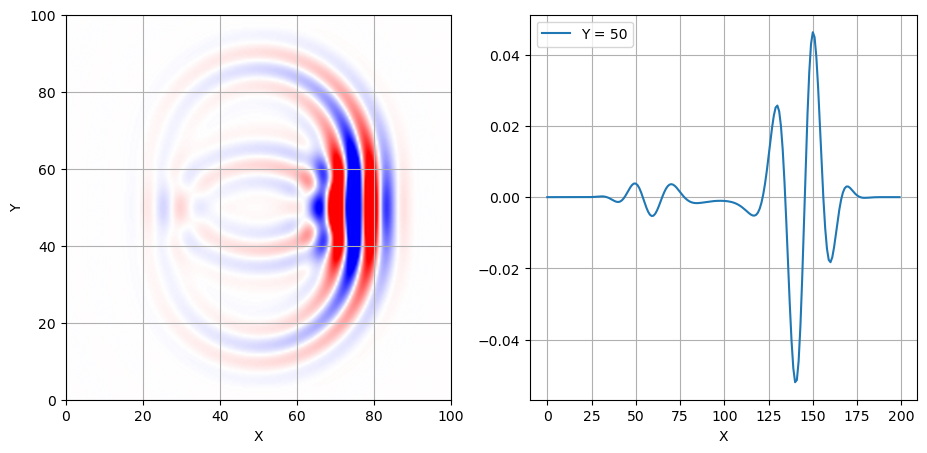

In [2]:

%matplotlib inline
import meep as mp 
import matplotlib.pyplot as plt


dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

sources = [mp.EigenModeSource(src=mp.GaussianSource(.1, width=5),
                center=mp.Vector3(0,0,0),
                size=mp.Vector3(y=25), 
                direction=mp.AUTOMATIC)]
                     
sim = mp.Simulation(cell_size=area, boundary_layers=[mp.PML(5.0)],
                geometry=[], sources=sources, resolution=2)

sim.reset_meep() 
sim.run(until=50)
data = sim.get_array(center=mp.Vector3(), size=area, component=mp.Ez)
src_plot(dx, dy, data.transpose())